# Discrete Wasserstein Distances on Small Markov-Chain Simplices

This notebook generates `fig:discrete-markov-simplex-distances`.  It visualizes the finite-state Wasserstein geometry induced by a reversible Markov chain and the logarithmic mean mobility.

For the two-state simplex $a_p=(p,1-p)$, the distance is the one-dimensional length
$$
    
    \mathcal{W}_K(a_p,a_{p_0})
    =\left|\int_{p_0}^p \frac{\mathrm d u}{\sqrt{\theta(u,1-u)}}\right|,
    \qquad
    \theta(a,b)=\frac{a-b}{\log a-\log b}.
$$
For the three-state complete-neighbor chain, the local norm is computed from the edge-flux formula in the manuscript.  The displayed distance to the uniform law is a shortest-path approximation on a triangular grid, using this local norm on each edge.  The right panel contrasts it with the ordinary Wasserstein distance for the discrete $0/1$ ground metric, for which $W_2^2$ is total variation.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")
sys.path.insert(0, str(FIGROOT))

import matplotlib.pyplot as plt
import matplotlib.tri as mtri
import numpy as np
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import dijkstra

from figure_style import BLUE, RED, VIOLET, GRAY, box_axes, figure_dir, interp_color, remove_axes, save_pdf, setup_matplotlib

setup_matplotlib()
OUT = figure_dir("discrete-markov-simplex-distances")
PNG_OUT = FIGROOT / "thumbnails"
PNG_OUT.mkdir(exist_ok=True)
CMAP = LinearSegmentedColormap.from_list("ot_red_violet_blue", [RED, VIOLET, BLUE])


## Logarithmic mean and the two-state distance

The two-state metric is a scalar Riemannian metric.  We evaluate the primitive of $1/\sqrt{\theta(p,1-p)}$ by trapezoidal quadrature and reuse it for several anchors $p_0$.

In [2]:
def log_mean(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    out = np.empty(np.broadcast(a, b).shape, dtype=float)
    aa, bb = np.broadcast_arrays(a, b)
    close = np.isclose(aa, bb, rtol=1e-10, atol=1e-14)
    out[close] = 0.5 * (aa[close] + bb[close])
    out[~close] = (aa[~close] - bb[~close]) / (np.log(aa[~close]) - np.log(bb[~close]))
    return out

p_grid = np.linspace(1e-4, 1 - 1e-4, 2600)
integrand = 1.0 / np.sqrt(log_mean(p_grid, 1.0 - p_grid))
primitive = np.zeros_like(p_grid)
primitive[1:] = np.cumsum(0.5 * (integrand[:-1] + integrand[1:]) * np.diff(p_grid))

p0_values = np.array([0.08, 0.22, 0.50, 0.78, 0.92])
primitive_p0 = np.interp(p0_values, p_grid, primitive)
curve_distances = [np.abs(primitive - s0) for s0 in primitive_p0]


## Three-state complete-neighbor chain

On $\Sigma_3$, the complete-neighbor walk has rates $K_{ij}=1/2$ for $i\neq j$.  For a small tangent vector $u$ at $p$, the local squared norm is obtained by minimizing the weighted edge-flux energy.  We build a triangular lattice and use Dijkstra's algorithm with edge length $\|\Delta p\|_{p+\Delta p/2}$ to approximate geodesic distance from the uniform point.

In [3]:
def local_norm_sigma3(p, u):
    p = np.maximum(np.asarray(p, dtype=float), 1e-8)
    p = p / p.sum()
    u = np.asarray(u, dtype=float)
    u = u - u.mean()
    a12 = 0.5 * float(log_mean(p[0], p[1]))
    a13 = 0.5 * float(log_mean(p[0], p[2]))
    a23 = 0.5 * float(log_mean(p[1], p[2]))
    D = 1.0 / a12 + 1.0 / a13 + 1.0 / a23
    q12 = (u[1] / a23 - u[0] / a13) / D
    q13 = -u[0] - q12
    q23 = q12 - u[1]
    val = q12**2 / a12 + q13**2 / a13 + q23**2 / a23
    return float(np.sqrt(max(val, 0.0)))

# Barycentric grid on the closed triangle.  The metric is evaluated at edge
# midpoints and clamped slightly away from the boundary to avoid log singularities.
N = 144
nodes = []
index = {}
for i in range(N + 1):
    for j in range(N + 1 - i):
        k = N - i - j
        idx = len(nodes)
        p = np.array([i, j, k], dtype=float) / N
        nodes.append(p)
        index[(i, j, k)] = idx
P = np.array(nodes)
center_idx = index[(N // 3, N // 3, N // 3)]

rows, cols, data = [], [], []
steps = [(1, -1, 0), (1, 0, -1), (0, 1, -1)]
for (i, j, k), idx in index.items():
    arr = np.array([i, j, k])
    for step in steps:
        nei = arr + np.array(step)
        if np.all(nei >= 0) and np.sum(nei) == N:
            key = tuple(int(v) for v in nei)
            jdx = index[key]
            p0, p1 = P[idx], P[jdx]
            midpoint = 0.5 * (p0 + p1)
            delta = p1 - p0
            w = local_norm_sigma3(midpoint, delta)
            rows.extend([idx, jdx])
            cols.extend([jdx, idx])
            data.extend([w, w])

G = coo_matrix((data, (rows, cols)), shape=(len(P), len(P))).tocsr()
dist_markov = dijkstra(G, directed=False, indices=center_idx)

# Ground distance d(i,j)=1 for i != j gives W_2^2 = TV on the simplex.
uniform = np.ones(3) / 3.0
dist_tv_w2 = np.sqrt(0.5 * np.sum(np.abs(P - uniform[None, :]), axis=1))

V = np.array([[0.0, np.sqrt(3) / 2.0], [-0.5, 0.0], [0.5, 0.0]])
XY = P @ V
tri = mtri.Triangulation(XY[:, 0], XY[:, 1])


## Exported panels

The PDFs do not contain embedded titles.  The manuscript arranges the three panels and explains the numerical approximation in the caption.

In [4]:
def plot_curves():
    fig, ax = plt.subplots(figsize=(2.85, 2.08))
    for r, (p0, dvals) in enumerate(zip(p0_values, curve_distances)):
        color = interp_color(r / (len(p0_values) - 1), RED, BLUE)
        ax.plot(p_grid, dvals, lw=1.25, color=color, label=rf"${p0:.2f}$")
        ax.scatter([p0], [0.0], s=14, color=color, edgecolor="white", linewidth=0.35, zorder=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.04 * max(d.max() for d in curve_distances))
    ax.set_xlabel(r"$p$", labelpad=1.5)
    ax.set_ylabel(r"$\mathcal{W}_K(a_p,a_{p_0})$", labelpad=2.0)
    ymax = 1.04 * max(d.max() for d in curve_distances)
    for r, p0 in enumerate(p0_values):
        color = interp_color(r / (len(p0_values) - 1), RED, BLUE)
        ax.text(p0, 0.055 * ymax, rf"${p0:.2f}$", color=color, ha="center", va="bottom", fontsize=6.15)
    ymax = 1.04 * max(d.max() for d in curve_distances)
    for r, p0 in enumerate(p0_values):
        color = interp_color(r / (len(p0_values) - 1), RED, BLUE)
        ax.text(p0, 0.055 * ymax, rf"${p0:.2f}$", color=color, ha="center", va="bottom", fontsize=6.15)
    ax.grid(True, color="#dddddd", lw=0.32, alpha=0.62)
    box_axes(ax)
    fig.tight_layout(pad=0.14)
    save_pdf(fig, OUT / "sigma2-curves.pdf", pad_inches=0.02)
    return fig


def draw_triangle_boundary(ax):
    closed = np.vstack([V, V[0]])
    ax.plot(closed[:, 0], closed[:, 1], color="#1f1f1f", lw=0.82, zorder=5)
    ax.scatter([0], [np.sqrt(3) / 6], s=15, color="#111111", edgecolor="white", linewidth=0.45, zorder=6)
    ax.text(V[0, 0], V[0, 1] + 0.040, r"$e_1$", ha="center", va="bottom", fontsize=7)
    ax.text(V[1, 0] - 0.035, V[1, 1] - 0.025, r"$e_2$", ha="right", va="top", fontsize=7)
    ax.text(V[2, 0] + 0.035, V[2, 1] - 0.025, r"$e_3$", ha="left", va="top", fontsize=7)
    ax.set_aspect("equal")
    ax.set_xlim(-0.565, 0.565)
    ax.set_ylim(-0.060, 0.910)
    remove_axes(ax)


def plot_simplex(values, path, *, contour_levels=10):
    fig, ax = plt.subplots(figsize=(2.18, 2.02))
    vmax = float(np.nanmax(values))
    levels = np.linspace(0.0, vmax, contour_levels)
    ax.tricontourf(tri, values, levels=np.linspace(0.0, vmax, 80), cmap=CMAP, alpha=0.32)
    ax.tricontour(tri, values, levels=levels[1:], colors="#24222a", linewidths=0.42, alpha=0.78)
    draw_triangle_boundary(ax)
    fig.tight_layout(pad=0.0)
    save_pdf(fig, path, pad_inches=0.02)
    return fig

fig_curves = plot_curves()
fig_markov = plot_simplex(dist_markov, OUT / "sigma3-markov-levels.pdf")
fig_tv = plot_simplex(dist_tv_w2, OUT / "sigma3-tv-levels.pdf")


## Thumbnail

The thumbnail is only for the notebook catalogue and MyST preview.  It combines the three generated panels in the same order as the paper.

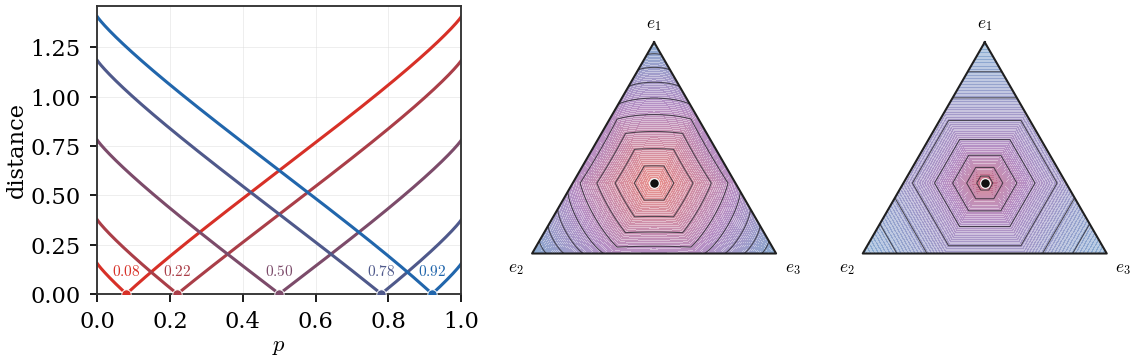

In [5]:
def make_thumbnail(path):
    fig = plt.figure(figsize=(7.35, 2.08))
    gs = fig.add_gridspec(1, 3, width_ratios=[1.32, 1.0, 1.0], wspace=0.18)
    ax = fig.add_subplot(gs[0, 0])
    for r, (p0, dvals) in enumerate(zip(p0_values, curve_distances)):
        color = interp_color(r / (len(p0_values) - 1), RED, BLUE)
        ax.plot(p_grid, dvals, lw=1.23, color=color)
        ax.scatter([p0], [0.0], s=14, color=color, edgecolor="white", linewidth=0.35, zorder=4)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.04 * max(d.max() for d in curve_distances))
    ax.set_xlabel(r"$p$", labelpad=1)
    ax.set_ylabel(r"distance", labelpad=1)
    ymax = 1.04 * max(d.max() for d in curve_distances)
    for r, p0 in enumerate(p0_values):
        color = interp_color(r / (len(p0_values) - 1), RED, BLUE)
        ax.text(p0, 0.055 * ymax, rf"${p0:.2f}$", color=color, ha="center", va="bottom", fontsize=6.15)
    ax.grid(True, color="#dddddd", lw=0.32, alpha=0.62)
    box_axes(ax)

    for k, vals in enumerate([dist_markov, dist_tv_w2], start=1):
        ax = fig.add_subplot(gs[0, k])
        vmax = float(np.nanmax(vals))
        levels = np.linspace(0.0, vmax, 10)
        ax.tricontourf(tri, vals, levels=np.linspace(0.0, vmax, 80), cmap=CMAP, alpha=0.32)
        ax.tricontour(tri, vals, levels=levels[1:], colors="#24222a", linewidths=0.42, alpha=0.78)
        draw_triangle_boundary(ax)
    fig.savefig(path, dpi=180, bbox_inches="tight", pad_inches=0.035)
    plt.close(fig)

make_thumbnail(PNG_OUT / "discrete-markov-simplex-distances.png")
display(Image(filename=str(PNG_OUT / "discrete-markov-simplex-distances.png")))
